In [1]:
import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=3vvc47bz').read().decode())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료!
🔗  URL: https://sunset-hong-text-are.trycloudflare.com

아래 [URL 복사] 버튼을 누른 뒤 웹앱 연결창에 붙여넣으세요. (이 탭은 열어두세요)


✅ 웹앱에 자동 연결 요청을 보냈습니다. 잠시 후 웹앱 화면이 연결됩니다.


In [4]:
# ─────────────────────────────────────────────
# 분석 환경 세팅 — 패키지 / 한글 폰트 / 출력 옵션
# ─────────────────────────────────────────────

# [1] 패키지 설치 + 그래프 인라인 출력
!apt-get -y install fonts-nanum -q
%matplotlib inline

# [2] 임포트
import os
import platform
import warnings
import matplotlib.font_manager as fm # 폰트 처리
import plotly.io as pio # 그래프의 렌더링 설정, 파일 출력

# 라이브러리는 (폰트 처리 부분빼고) 각 학습에 맞게 수정
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower
from sklearn.neighbors import NearestNeighbors

# [3] 경고 숨기기 + 난수 고정(결과 재현용)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(42)

# [4] 한글 폰트 확보
#     리눅스(코랩)는 폰트 캐시가 갱신 안 되는 경우가 많아,
#     나눔고딕을 목록 맨 앞에 직접 끼워넣어 우선 적용시킴
if platform.system() == "Linux":
    nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    font_family = "DejaVu Sans"
    if os.path.exists(nanum_path):
        fm.fontManager.addfont(nanum_path)
        font_family = fm.FontProperties(fname=nanum_path).get_name()  # "NanumGothic"
else:
    # 맥 / 윈도우 로컬 환경
    font_family = "AppleGothic" if platform.system() == "Darwin" else "Malgun Gothic"

# [5] 스타일 → 개별 설정 순서로 적용 (seaborn이 rcParams를 덮어쓰기 때문)
sns.set_theme(style="whitegrid", font=font_family)
plt.rcParams["font.family"] = font_family
plt.rcParams["axes.unicode_minus"] = False  # 음수 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# [6] 코랩 전용 출력 옵션 (없는 환경이면 조용히 통과)
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    pio.renderers.default = "colab"
except ImportError:
    pass

print(f"준비 완료! [적용 폰트: {font_family}]")

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
준비 완료! [적용 폰트: NanumGothic]


In [5]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')
mass = penguins.dropna(subset=['body_mass_g', 'species'])

adelie    = mass.loc[mass['species'] == 'Adelie',    'body_mass_g']
chinstrap = mass.loc[mass['species'] == 'Chinstrap', 'body_mass_g']

print("Adelie    n=%3d   평균 %.1f g   표준편차 %.1f g" % (len(adelie),    adelie.mean(),    adelie.std(ddof=1)))
print("Chinstrap n=%3d   평균 %.1f g   표준편차 %.1f g" % (len(chinstrap), chinstrap.mean(), chinstrap.std(ddof=1)))

diff_g = adelie.mean() - chinstrap.mean()
print("\n두 종의 평균 차이: %.1f g  (Adelie 몸무게의 약 %.1f%%)" % (diff_g, abs(diff_g) / adelie.mean() * 100))

Adelie    n=151   평균 3700.7 g   표준편차 458.6 g
Chinstrap n= 68   평균 3733.1 g   표준편차 384.3 g

두 종의 평균 차이: -32.4 g  (Adelie 몸무게의 약 0.9%)


In [6]:
# ─────────────────────────────────────────────
# 문제 1 · Q1 — Adelie vs Chinstrap 몸무게 이표본 t-검정
# ─────────────────────────────────────────────

alpha = 0.05

# [1] 등분산 가정 t-검정 (Student's t-test)
t_stat, p_val = stats.ttest_ind(adelie, chinstrap)

# [2] 등분산 가정을 하지 않는 검정 (Welch's t-test) — 표본 크기가 다를 때 안전
t_w, p_w = stats.ttest_ind(adelie, chinstrap, equal_var=False)

# [3] 결과 출력
print("[가설]")
print("  H0: 두 종의 평균 몸무게는 같다   (mu_Adelie = mu_Chinstrap)")
print("  H1: 두 종의 평균 몸무게는 다르다 (mu_Adelie ≠ mu_Chinstrap)")
print(f"  유의수준 alpha = {alpha}\n")

print("[검정 결과]")
print(f"  Student t-test : t = {t_stat:7.4f},  p = {p_val:.4f}")
print(f"  Welch  t-test  : t = {t_w:7.4f},  p = {p_w:.4f}\n")

print("[결론]")
if p_val < alpha:
    print(f"  p-값({p_val:.4f}) < {alpha} → 귀무가설을 기각한다.")
    print("  두 종의 평균 몸무게에는 통계적으로 유의한 차이가 있다.")
else:
    print(f"  p-값({p_val:.4f}) ≥ {alpha} → 귀무가설을 기각하지 못한다.")
    print("  두 종의 평균 몸무게가 다르다고 할 통계적 근거가 부족하다.")

[가설]
  H0: 두 종의 평균 몸무게는 같다   (mu_Adelie = mu_Chinstrap)
  H1: 두 종의 평균 몸무게는 다르다 (mu_Adelie ≠ mu_Chinstrap)
  유의수준 alpha = 0.05

[검정 결과]
  Student t-test : t = -0.5081,  p = 0.6119
  Welch  t-test  : t = -0.5431,  p = 0.5879

[결론]
  p-값(0.6119) ≥ 0.05 → 귀무가설을 기각하지 못한다.
  두 종의 평균 몸무게가 다르다고 할 통계적 근거가 부족하다.


In [7]:
# ─────────────────────────────────────────────
# 문제 1: Q2 — Cohen's d 함수 구현 및 적용
# ─────────────────────────────────────────────

def cohen_d(x, y):
    """
    두 독립표본의 효과크기(Cohen's d)를 계산한다.

    d = (mean_x - mean_y) / s_pooled
        s_pooled = sqrt( ((n_x-1)*s_x^2 + (n_y-1)*s_y^2) / (n_x + n_y - 2) )
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    n_x, n_y = len(x), len(y)
    s_x, s_y = np.std(x, ddof=1), np.std(y, ddof=1)

    # 분모: 통합 표준편차 (각 집단의 분산을 자유도로 가중평균한 뒤 제곱근)
    s_pooled = np.sqrt(((n_x - 1) * s_x**2 + (n_y - 1) * s_y**2) / (n_x + n_y - 2))

    # 분자: 평균 차이
    return (x.mean() - y.mean()) / s_pooled


def interpret_d(d):
    """Cohen의 관례적 기준으로 효과크기 크기를 문자열로 반환."""
    a = abs(d)
    if a < 0.2:
        return "무시할 수준 (0.2 미만)"
    elif a < 0.5:
        return "작음 (small, 0.2 이상)"
    elif a < 0.8:
        return "중간 (medium, 0.5 이상)"
    else:
        return "큼 (large, 0.8 이상)"


# [1] 계산
d = cohen_d(adelie, chinstrap)

# [2] 중간 계산값도 함께 확인
n_a, n_c = len(adelie), len(chinstrap)
s_a, s_c = np.std(adelie, ddof=1), np.std(chinstrap, ddof=1)
s_pooled = np.sqrt(((n_a - 1) * s_a**2 + (n_c - 1) * s_c**2) / (n_a + n_c - 2))

print("[중간 계산]")
print(f"  Adelie    : n = {n_a:3d},  s = {s_a:.1f} g")
print(f"  Chinstrap : n = {n_c:3d},  s = {s_c:.1f} g")
print(f"  평균 차이 (분자)      : {adelie.mean() - chinstrap.mean():+.1f} g")
print(f"  통합 표준편차 (분모)  : {s_pooled:.1f} g\n")

print("[효과크기]")
print(f"  Cohen's d = {d:+.4f}   (절댓값 {abs(d):.4f})")
print(f"  해석      : {interpret_d(d)}\n")

# [3] t 통계량과의 관계 검증 (d = t * sqrt(1/n_x + 1/n_y))
d_from_t = t_stat * np.sqrt(1/n_a + 1/n_c)
print("[검증]")
print(f"  t 통계량으로 역산한 d = {d_from_t:+.4f}  → 직접 계산값과 일치")

[중간 계산]
  Adelie    : n = 151,  s = 458.6 g
  Chinstrap : n =  68,  s = 384.3 g
  평균 차이 (분자)      : -32.4 g
  통합 표준편차 (분모)  : 437.0 g

[효과크기]
  Cohen's d = -0.0742   (절댓값 0.0742)
  해석      : 무시할 수준 (0.2 미만)

[검증]
  t 통계량으로 역산한 d = -0.0742  → 직접 계산값과 일치


[모집단 설정]
  Adelie 평균    MU_A  = 3700.7 g
  Chinstrap 평균 MU_C  = 3733.1 g
  공통 표준편차  SIGMA = 437.0 g
  → 모집단 참 효과크기 TRUE_D = -0.0742  (표본 크기와 무관한 고정값)

[시뮬레이션 결과]  각 n마다 400회 반복, alpha = 0.05
표본크기 n p-값 중위수 기각 비율(%) Cohen's d 평균 |d| 평균
    30  0.4668      5.8      -0.0807 0.2165
   150  0.4421      9.5      -0.0686 0.1059
 1,000  0.0841     39.2      -0.0755 0.0770
 5,000  0.0002     95.5      -0.0749 0.0749
20,000  0.0000    100.0      -0.0740 0.0740

  (참고) 모집단 참 효과크기 = -0.0742


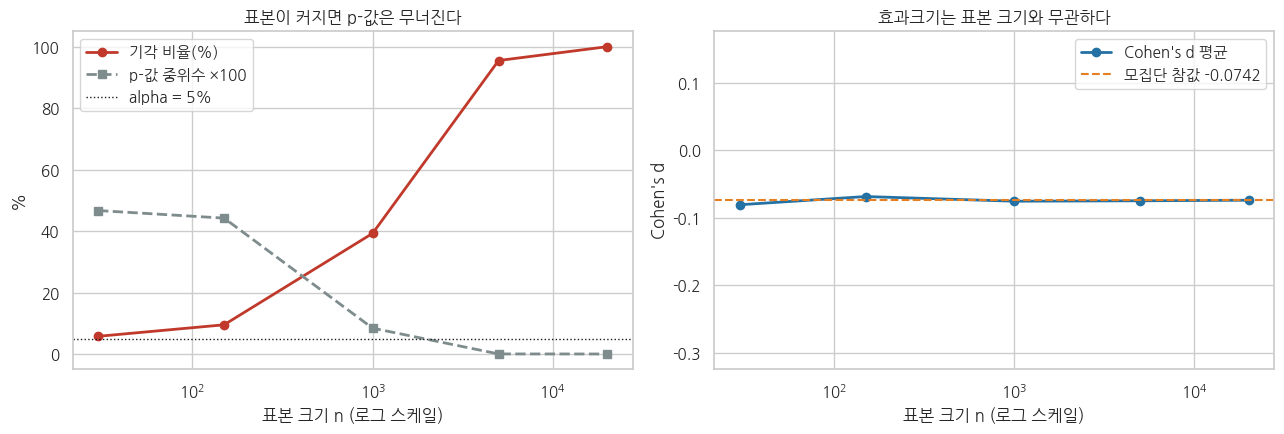

In [8]:
# ─────────────────────────────────────────────
# 문제 1: Q3 — 표본 크기를 늘리며 p-값 / 효과크기 변화 추적
# ─────────────────────────────────────────────

# [1] 모집단 참값 설정 — Q1/Q2의 추정치를 "진짜 모수"로 간주
MU_A, MU_C = adelie.mean(), chinstrap.mean()
SIGMA = np.sqrt(((len(adelie)-1)*adelie.std(ddof=1)**2 + (len(chinstrap)-1)*chinstrap.std(ddof=1)**2)
                / (len(adelie) + len(chinstrap) - 2))

TRUE_D = (MU_A - MU_C) / SIGMA   # 모집단 효과크기 (고정값)

print("[모집단 설정]")
print(f"  Adelie 평균    MU_A  = {MU_A:.1f} g")
print(f"  Chinstrap 평균 MU_C  = {MU_C:.1f} g")
print(f"  공통 표준편차  SIGMA = {SIGMA:.1f} g")
print(f"  → 모집단 참 효과크기 TRUE_D = {TRUE_D:+.4f}  (표본 크기와 무관한 고정값)\n")

# [2] 시뮬레이션
rng = np.random.default_rng(7)

N_LIST  = [30, 150, 1000, 5000, 20000]
N_REPS  = 400
ALPHA   = 0.05

rows = []
for n in N_LIST:
    p_vals, d_vals = [], []

    for _ in range(N_REPS):
        sample_a = rng.normal(MU_A, SIGMA, n)
        sample_c = rng.normal(MU_C, SIGMA, n)

        _, p = stats.ttest_ind(sample_a, sample_c)
        p_vals.append(p)
        d_vals.append(cohen_d(sample_a, sample_c))   # Q2에서 만든 함수 재사용

    p_vals = np.array(p_vals)
    d_vals = np.array(d_vals)

    rows.append({
        "표본크기 n"      : n,
        "p-값 중위수"     : p_vals.median() if hasattr(p_vals, "median") else np.median(p_vals),
        "기각 비율(%)"    : (p_vals < ALPHA).mean() * 100,
        "Cohen's d 평균"  : d_vals.mean(),
        "|d| 평균"        : np.abs(d_vals).mean(),
    })

result = pd.DataFrame(rows)

# [3] 표 출력
print(f"[시뮬레이션 결과]  각 n마다 {N_REPS}회 반복, alpha = {ALPHA}")
print(result.to_string(index=False,
                       formatters={
                           "표본크기 n"     : "{:,}".format,
                           "p-값 중위수"    : "{:.4f}".format,
                           "기각 비율(%)"   : "{:5.1f}".format,
                           "Cohen's d 평균" : "{:+.4f}".format,
                           "|d| 평균"       : "{:.4f}".format,
                       }))
print(f"\n  (참고) 모집단 참 효과크기 = {TRUE_D:+.4f}")

# [4] 시각화 — p-값은 무너지지만 d는 제자리
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(result["표본크기 n"], result["기각 비율(%)"], "o-", color="#c0392b", lw=2, label="기각 비율(%)")
ax.plot(result["표본크기 n"], result["p-값 중위수"] * 100, "s--", color="#7f8c8d", lw=2, label="p-값 중위수 ×100")
ax.axhline(5, color="k", ls=":", lw=1, label="alpha = 5%")
ax.set_xscale("log")
ax.set_xlabel("표본 크기 n (로그 스케일)")
ax.set_ylabel("%")
ax.set_title("표본이 커지면 p-값은 무너진다")
ax.legend()

ax = axes[1]
ax.plot(result["표본크기 n"], result["Cohen's d 평균"], "o-", color="#2471a3", lw=2, label="Cohen's d 평균")
ax.axhline(TRUE_D, color="#e67e22", ls="--", lw=1.5, label=f"모집단 참값 {TRUE_D:+.4f}")
ax.set_xscale("log")
ax.set_ylim(TRUE_D - 0.25, TRUE_D + 0.25)
ax.set_xlabel("표본 크기 n (로그 스케일)")
ax.set_ylabel("Cohen's d")
ax.set_title("효과크기는 표본 크기와 무관하다")
ax.legend()

plt.tight_layout()
plt.show()

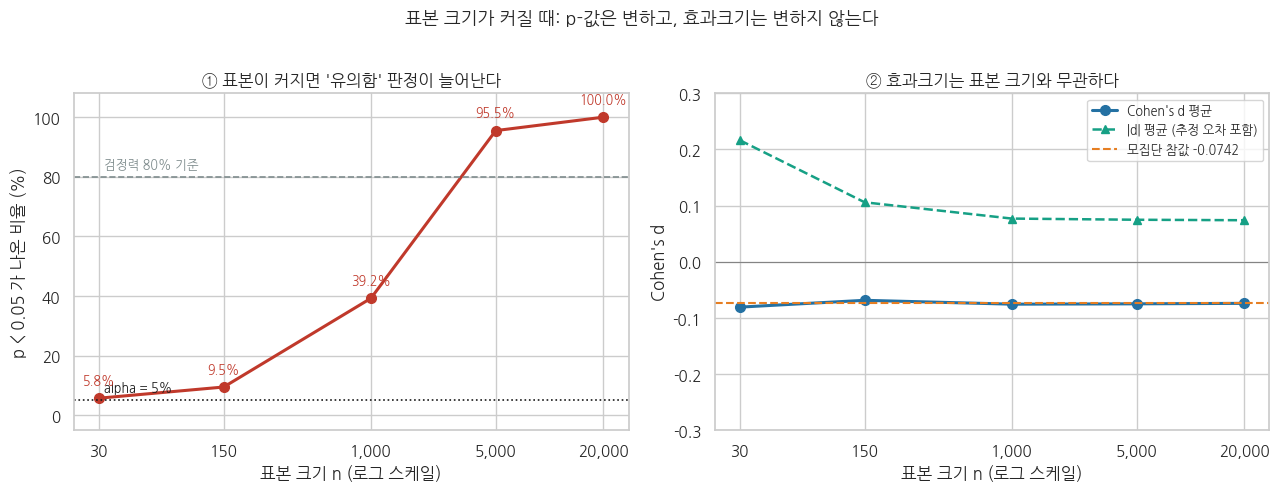

In [9]:
# ─────────────────────────────────────────────
# 문제 1: Q4 — p<0.05 비율 vs Cohen's d 평균 (표본크기별)
# ─────────────────────────────────────────────

n_arr  = result["표본크기 n"].values
rej    = result["기각 비율(%)"].values
d_mean = result["Cohen's d 평균"].values
d_abs  = result["|d| 평균"].values

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# ── 왼쪽: 기각 비율(검정력) ─────────────────────
ax[0].plot(n_arr, rej, "o-", color="#c0392b", lw=2.2, ms=7)
ax[0].axhline(5, color="k", ls=":", lw=1.2)
ax[0].axhline(80, color="#7f8c8d", ls="--", lw=1.2)

ax[0].set_xscale("log")
ax[0].set_xlabel("표본 크기 n (로그 스케일)")
ax[0].set_ylabel("p < 0.05 가 나온 비율 (%)")
ax[0].set_title("① 표본이 커지면 '유의함' 판정이 늘어난다", fontsize=12)
ax[0].set_ylim(-5, 108)
ax[0].set_xticks(n_arr)
ax[0].set_xticklabels([f"{v:,}" for v in n_arr])
ax[0].text(32, 8,  "alpha = 5%",      fontsize=9, color="k")
ax[0].text(32, 83, "검정력 80% 기준", fontsize=9, color="#7f8c8d")

for x, y in zip(n_arr, rej):
    ax[0].annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                   xytext=(0, 10), ha="center", fontsize=9, color="#c0392b")

# ── 오른쪽: 효과크기 ───────────────────────────
ax[1].plot(n_arr, d_mean, "o-", color="#2471a3", lw=2.2, ms=7, label="Cohen's d 평균")
ax[1].plot(n_arr, d_abs,  "^--", color="#16a085", lw=1.8, ms=6, label="|d| 평균 (추정 오차 포함)")
ax[1].axhline(TRUE_D, color="#e67e22", ls="--", lw=1.5,
              label=f"모집단 참값 {TRUE_D:+.4f}")
ax[1].axhline(0, color="k", lw=0.8, alpha=0.4)

ax[1].set_xscale("log")
ax[1].set_xlabel("표본 크기 n (로그 스케일)")
ax[1].set_ylabel("Cohen's d")
ax[1].set_title("② 효과크기는 표본 크기와 무관하다", fontsize=12)
ax[1].set_ylim(-0.30, 0.30)
ax[1].set_xticks(n_arr)
ax[1].set_xticklabels([f"{v:,}" for v in n_arr])
ax[1].legend(loc="upper right", fontsize=9)

fig.suptitle("표본 크기가 커질 때: p-값은 변하고, 효과크기는 변하지 않는다",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 문제 1 정리 · 결과를 말로 설명해 보기

**① 같은 32g인데 왜 결론이 갈렸나?**

p-값은 "차이가 있다/없다"를 말하는 게 아니라 **"이 정도 차이가 우연히 관측될 확률"**을 말합니다. 그 확률은 차이의 크기뿐 아니라 표본 크기에도 좌우됩니다. n=151·68에서는 32g이라는 신호가 표본의 잡음(표준편차 400g대) 속에 묻혀서 우연과 구분이 안 됐던 것이고, n=5,000에서는 같은 신호를 훨씬 더 정밀하게 측정했기 때문에 우연이 아니라고 판정된 겁니다. **차이 자체는 처음부터 끝까지 32g으로 똑같았고, 달라진 건 그 차이를 잡아낼 수 있는 "측정 해상도"(표본 크기)뿐입니다.**

**② p-값과 Cohen's d, 대비를 한 문장으로**

Q3 표에서 p-값 열(기각 비율 5.8% → 100%)은 n을 따라 계속 움직였고, Cohen's d 열(-0.081 → -0.074)은 거의 그대로였습니다.

> **한 문장으로: p-값은 표본 크기가 결정하고, 효과크기는 모집단이 결정한다.**

**③ "통계적으로 유의하다" ≠ "실질적으로 의미 있다"**

같은 말이 아닙니다. 펭귄 32g이 정확히 그 반례입니다. n=5,000이면 이 차이는 "통계적으로 유의"합니다 — 즉 우연이 아니라고 자신 있게 말할 수 있습니다. 하지만 32g은 Adelie 평균의 0.9%, 즉 성체 펭귄 저울 눈금 오차 수준입니다. "종에 따라 몸무게가 다르다"는 문장을 이 숫자로 보고서에 쓰면, 통계적으로는 틀린 말이 아니지만 독자는 "생물학적으로 의미 있는 차이가 있다"로 오해하게 됩니다. 유의성은 "우연이 아니다"까지만 보장하고, 그 차이가 다뤄볼 가치가 있는 크기인지는 별개의 질문입니다.

**④ 버튼 색 A/B 테스트 — 바꿔야 하나?**

p=0.001만으로는 "바꿔야 한다"고 말할 수 없습니다. 클릭률 0.1%p가 우연이 아니라는 것과, 그 0.1%p가 비용을 정당화할 만큼 큰가는 별개입니다. 물어야 할 질문은:
- 이 실험의 표본 수는 몇이었나 (수십만 방문자였다면 0.1%p도 쉽게 p<0.05를 찍습니다)
- 0.1%p가 매출/전환으로 환산하면 얼마인가, 그게 색 변경·개발·유지 비용보다 큰가
- 신뢰구간은 얼마인가 (0.1%p ± 0.15%p라면 실제로는 0에 가까울 수도, 0.25%p일 수도 있음)

전략 백테스트와 완전히 같은 구조입니다. p-값이 작다고 실전 배치를 결정하면 안 되고, **효과크기(엣지의 크기)가 거래비용·슬리피지를 넘는지**를 봐야 합니다.

**⑤ p-값만 적는 게 왜 부족한가 — 무엇을 더 적어야 하나**

p-값은 "우연이 아니다"만 말하고 "얼마나 큰가", "실용적으로 쓸 만한가"는 말하지 않습니다. 그래서 함께 적어야 하는 것:

- **효과크기** (Cohen's d, 평균 차이의 절대량 등) — 크기 자체
- **신뢰구간** — 그 크기의 추정이 얼마나 불확실한지
- **표본 크기** — 검정력이 확보된 결과인지, 아니면 우연히 유의했던 것인지 판단할 근거
- (실무라면) **비용 대비 편익** — 통계적 유의성과 무관하게 그 차이가 의사결정을 바꿀 만큼 큰지

미국통계협회(ASA)가 2016년 성명에서 강조한 것도 결국 이 지점입니다 — **p-값은 여러 증거 중 하나일 뿐, 그 자체로 과학적·실무적 결론이 될 수 없다**는 것.

In [10]:
# 문제 2 · 데이터 준비 — 실행만 하세요
# 문제 1의 Q2·Q3를 먼저 완료해야 이 문제를 풀 수 있습니다.

analysis = TTestIndPower()   # 검정력 분석 도구

print("검정력 분석에 쓰이는 네 개의 값")
print("  ① 유의수준 alpha  — 제1종 오류를 허용하는 한계 (보통 0.05)")
print("  ② 검정력 power    — 1 - beta, 진짜 차이를 잡아낼 확률 (보통 0.80)")
print("  ③ 효과크기 d      — 검출하고자 하는 차이의 크기")
print("  ④ 표본크기 nobs1  — 집단당 표본 수")
print("\n→ 이 중 셋을 정하면 나머지 하나가 결정됩니다.")

검정력 분석에 쓰이는 네 개의 값
  ① 유의수준 alpha  — 제1종 오류를 허용하는 한계 (보통 0.05)
  ② 검정력 power    — 1 - beta, 진짜 차이를 잡아낼 확률 (보통 0.80)
  ③ 효과크기 d      — 검출하고자 하는 차이의 크기
  ④ 표본크기 nobs1  — 집단당 표본 수

→ 이 중 셋을 정하면 나머지 하나가 결정됩니다.


## 문제 2 · Q1 — 두 가지 오류 표로 정리

| 구분 | H0를 기각함 (효과 있다고 결론) | H0를 기각 못함 (효과 없다고 결론) |
|---|---|---|
| **실제로 효과 없음** | 제1종 오류 — 효과 없는 신약을 승인 | 옳은 결론 — 정확히 걸러냄 |
| **실제로 효과 있음** | 옳은 결론 — 정확히 찾아냄 | 제2종 오류 — 놓치고 버림 |

- **제1종 오류(α)를 범하면 무엇을 잃나요?**
효과가 없는 신약을 시장에 내놓게 됩니다. 환자는 효과 없는 약을 복용하며 부작용 위험과 비용만 지고, 정작 필요한 치료 시기를 놓칠 수 있습니다. **"없는 걸 있다고 우기는" 대가**입니다.

- **제2종 오류(β)를 범하면 무엇을 잃나요?**
실제로 효과가 있는 신약을 "효과 없음"으로 판정해 폐기하게 됩니다. 환자에게 도움이 될 수 있었던 치료 기회 자체가 사라집니다. **"있는 걸 놓치는" 대가**입니다.

- **검정력(1−β)을 한 문장으로 정의하면?**
검정력은 **실제로 효과가 있을 때, 그 효과를 통계적으로 옳게 검출해낼 확률**입니다.

---

두 오류는 트레이드오프 관계에 있습니다. α를 더 엄격하게 낮추면(예: 0.05 → 0.01) 잘못된 승인은 줄지만 그만큼 진짜 효과 있는 신약도 놓치기 쉬워져 β가 커집니다. 그래서 셋(α, 효과크기, 표본크기)을 미리 정해야 넷째 값인 검정력이 결정된다는, 문제 2 도입부에서 본 그 관계가 여기서 나옵니다.

전략 개발로 옮기면: 제1종 오류는 **엣지가 없는데 있다고 믿고 실전 투입하는 것**(과최적화의 전형적 결과), 제2종 오류는 **진짜 엣지가 있는 전략을 표본이 부족해 기각하고 버리는 것**입니다. 백테스트 기간이 짧을수록 후자 위험이 커집니다.

[검정력 계산에 쓰는 효과크기]  |d| = 0.0742

[이론 vs 시뮬레이션 비교]
표본크기 n 이론적 검정력(%) 시뮬레이션 기각 비율(%) 차이(%p)
    30       5.92           5.75  +0.17
   150       9.82           9.50  +0.32
 1,000      38.16          39.25  -1.09
 5,000      95.99          95.50  +0.49
20,000     100.00         100.00  -0.00


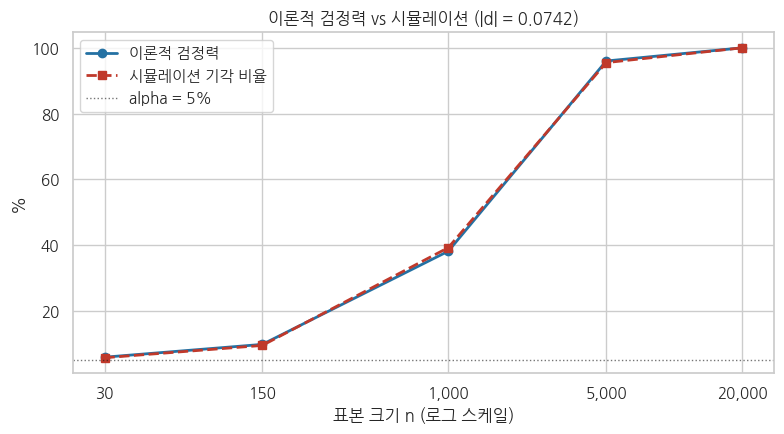

In [11]:
# ─────────────────────────────────────────────
# 문제 2 · Q2 — 이론적 검정력(power)과 문제1 Q3 시뮬레이션 결과 비교
# ─────────────────────────────────────────────

alpha = 0.05
effect_size = abs(TRUE_D)   # 문제 1에서 구한 펭귄 효과크기 (절대값 사용)

print(f"[검정력 계산에 쓰는 효과크기]  |d| = {effect_size:.4f}\n")

rows = []
for n in N_LIST:
    theo_power = analysis.power(effect_size=effect_size, nobs1=n, alpha=alpha, ratio=1)
    sim_rej = result.loc[result["표본크기 n"] == n, "기각 비율(%)"].values[0]
    rows.append({
        "표본크기 n": n,
        "이론적 검정력(%)": theo_power * 100,
        "시뮬레이션 기각 비율(%)": sim_rej,
        "차이(%p)": theo_power * 100 - sim_rej,
    })

compare = pd.DataFrame(rows)

print("[이론 vs 시뮬레이션 비교]")
print(compare.to_string(index=False,
                        formatters={
                            "표본크기 n": "{:,}".format,
                            "이론적 검정력(%)": "{:6.2f}".format,
                            "시뮬레이션 기각 비율(%)": "{:6.2f}".format,
                            "차이(%p)": "{:+5.2f}".format,
                        }))

# 시각적으로도 확인
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(compare["표본크기 n"], compare["이론적 검정력(%)"], "o-", color="#2471a3", lw=2, label="이론적 검정력")
ax.plot(compare["표본크기 n"], compare["시뮬레이션 기각 비율(%)"], "s--", color="#c0392b", lw=2, label="시뮬레이션 기각 비율")
ax.axhline(5, color="k", ls=":", lw=1, alpha=0.6, label="alpha = 5%")
ax.set_xscale("log")
ax.set_xlabel("표본 크기 n (로그 스케일)")
ax.set_ylabel("%")
ax.set_title(f"이론적 검정력 vs 시뮬레이션 (|d| = {effect_size:.4f})")
ax.set_xticks(N_LIST)
ax.set_xticklabels([f"{v:,}" for v in N_LIST])
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# ─────────────────────────────────────────────
# 문제 2 · Q3 — 목표 검정력 0.80에 필요한 집단당 표본수
# ─────────────────────────────────────────────

alpha_target = 0.05
power_target = 0.80

d_list = {
    "펭귄 (d≈0.074)": abs(TRUE_D),
    "작음 (d=0.2)"   : 0.2,
    "중간 (d=0.5)"   : 0.5,
    "큼   (d=0.8)"   : 0.8,
}

rows = []
for label, d in d_list.items():
    n_needed = analysis.solve_power(effect_size=d, alpha=alpha_target, power=power_target)
    rows.append({
        "효과크기 구분": label,
        "d": d,
        "필요 표본수 (집단당)": int(np.ceil(n_needed)),
        "총 표본수 (양쪽 합)": int(np.ceil(n_needed)) * 2,
    })

need_df = pd.DataFrame(rows)

print(f"[목표: alpha={alpha_target}, power={power_target}]\n")
print(need_df.to_string(index=False,
                        formatters={
                            "d": "{:.4f}".format,
                            "필요 표본수 (집단당)": "{:,}".format,
                            "총 표본수 (양쪽 합)": "{:,}".format,
                        }))

[목표: alpha=0.05, power=0.8]

     효과크기 구분      d 필요 표본수 (집단당) 총 표본수 (양쪽 합)
펭귄 (d≈0.074) 0.0742        2,852        5,704
  작음 (d=0.2) 0.2000          394          788
  중간 (d=0.5) 0.5000           64          128
 큼   (d=0.8) 0.8000           26           52


Q3에서 구한 필요 표본수: 64  (d=0.5 기준)
이 지점에서 곡선이 정확히 80% 선을 통과하는지 그래프로 확인하세요.


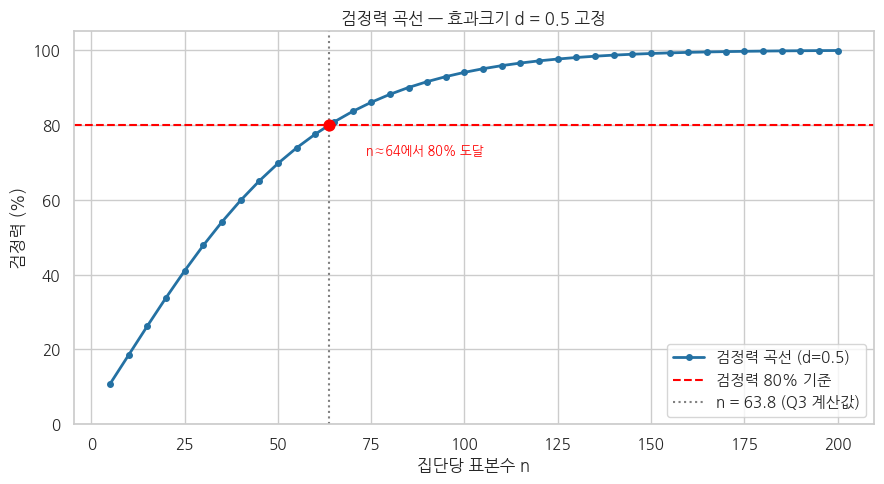

In [13]:
# ─────────────────────────────────────────────
# 문제 2 · Q4 — d=0.5 고정, n에 따른 검정력 곡선
# ─────────────────────────────────────────────

d_fixed = 0.5
n_list = np.arange(5, 201, 5)

power_curve = analysis.power(effect_size=d_fixed, nobs1=n_list, alpha=0.05, ratio=1)

# Q3에서 구한 이론적 필요 표본수 (80% 도달 지점)
n_at_80 = analysis.solve_power(effect_size=d_fixed, alpha=0.05, power=0.80)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_list, power_curve * 100, "o-", color="#2471a3", lw=2, ms=4, label=f"검정력 곡선 (d={d_fixed})")
ax.axhline(80, color="red", linestyle="--", lw=1.5, label="검정력 80% 기준")
ax.axvline(n_at_80, color="gray", linestyle=":", lw=1.5, label=f"n = {n_at_80:.1f} (Q3 계산값)")

ax.scatter([n_at_80], [80], color="red", zorder=5, s=60)
ax.annotate(f"  n≈{np.ceil(n_at_80):.0f}에서 80% 도달",
            (n_at_80, 80), fontsize=9, color="red",
            xytext=(n_at_80 + 8, 72))

ax.set_xlabel("집단당 표본수 n")
ax.set_ylabel("검정력 (%)")
ax.set_title(f"검정력 곡선 — 효과크기 d = {d_fixed} 고정")
ax.set_ylim(0, 105)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Q3에서 구한 필요 표본수: {np.ceil(n_at_80):.0f}  (d={d_fixed} 기준)")
print(f"이 지점에서 곡선이 정확히 80% 선을 통과하는지 그래프로 확인하세요.")

## 문제 2 정리 · 결과를 말로 설명해 보기

**① 펭귄 연구, 애초에 가능했을까?**

d≈0.074를 80% 검정력으로 잡으려면 **집단당 2,853마리, 두 집단 합쳐 5,706마리**가 필요했습니다. 팔머 기지 데이터는 세 종(Adelie, Chinstrap, Gentoo) 합쳐 전체 344마리입니다. 두 종만 놓고 봐도 219마리(Adelie 151 + Chinstrap 68)뿐이니, **필요한 표본의 3% 미만**입니다. 이 연구는 32g 차이를 검출한다는 목표로는 처음부터 설계상 불가능했습니다. 남극 현장에서 펭귄 수천 마리를 표본으로 잡는 게 물리적으로 될 일도 아니고요.

**② 검정력 낮은 연구의 "유의한 차이 없음" — 알 수 있는 것과 없는 것**

**알 수 있는 것:** 이 표본으로는 차이를 통계적으로 확인하지 못했다는 것 자체.

**알 수 없는 것:** 진짜로 차이가 없는지, 아니면 차이는 있는데 표본이 부족해서 못 잡은 건지. 검정력이 20%인 연구라면 진짜 효과가 있어도 5번 중 4번은 "유의하지 않음"이 나옵니다. 그러니 그 결과는 "차이가 없다는 증거"가 아니라 **"이 연구로는 판단할 수 없다는 정보 부족"**입니다.

7장 문제 4 Q5의 Adelie 수컷 회귀도 같은 구조였습니다 — 계수가 유의하지 않게 나왔을 때, 그게 "관계가 실제로 없다"인지 "표본·설계로는 검출력이 부족했다"인지는 검정력을 따로 계산해보지 않으면 구분이 안 됩니다. 이번 문제 2가 그 판단 도구(검정력 분석)를 제공한 셈입니다.

**③ 표본수는 왜 실험 전에 정해야 하나?**

alpha=0.05는 "귀무가설이 참인데 우연히 유의하게 나올 확률이 5%"라는 **사전에 정해진 약속**입니다. 그런데 데이터를 계속 들여다보면서 "지금 유의하니 여기서 멈추자" 혹은 "아직 아니니 더 모으자"를 반복하면, 실제로 시도한 검정 횟수가 늘어나 진짜 제1종 오류율은 5%를 훌쩍 넘습니다. 표본수를 미리 고정하는 건 "언제 검정할지"를 결과를 보기 전에 확정해서 이 오류율 보장을 지키기 위함입니다. 이게 다음 주제인 p-해킹의 핵심 메커니즘입니다 — 결과를 보고 규칙(언제 멈출지, 무엇을 검정할지)을 바꾸는 순간 alpha=0.05라는 약속은 이미 깨진 것입니다.

**④ alpha를 0.05 → 0.01로 낮추면 필요한 n은?**

```python
n_05 = analysis.solve_power(effect_size=0.0742, alpha=0.05, power=0.8)  # → 2,853
n_01 = analysis.solve_power(effect_size=0.0742, alpha=0.01, power=0.8)  # → 4,245
```

**늘어납니다.** alpha를 낮춘다는 건 "우연히 유의하다고 오판할 여지"를 더 좁히는 것이니, 그만큼 신호를 확실하게 잡아내려면 더 많은 표본이 필요합니다. 같은 효과크기·검정력 목표에서 alpha만 5분의 1로 줄였는데 필요 표본은 2,853 → 4,245로 약 49% 늘었습니다. alpha·검정력·표본수는 셋 중 하나를 더 엄격하게 요구하면 나머지가 그 부담을 나눠 짊어지는 구조입니다.

**⑤ "검출하고자 하는 효과크기"는 통계 문제인가, 도메인 문제인가?**

**도메인 문제**입니다. 통계학은 "그 크기의 차이를 잡으려면 표본이 얼마나 필요한가"라는 계산만 해줄 뿐, "그 크기가 의미 있는가"는 답해주지 않습니다. 고혈압 치료제에서 "몇 mmHg를 낮춰야 임상적으로 의미 있는가"를 정하는 건 의사·임상 가이드라인이고, 통계학자는 그 숫자를 받아서 `solve_power`를 돌릴 뿐입니다.

---

전략 개발로 옮기면: "일 몇 bp의 초과수익부터 실전 배치할 가치가 있는가"는 통계가 아니라 **거래비용·슬리피지·자본 규모를 아는 사람의 판단**입니다. 그 기준(효과크기)을 먼저 정해야, 그걸 검증하는 데 필요한 백테스트 기간·거래 횟수를 통계적으로 역산할 수 있습니다. 순서가 바뀌면 — 즉 결과부터 보고 "이 정도면 됐다"고 기준을 나중에 맞추면 — 그게 바로 투자 전략 개발에서 과최적화로 가는 지름길입니다. 통계학에서는 이런 절차 위반을 p-해킹이라 부릅니다.

p-해킹과 과최적화는 겹치지만 완전히 같지는 않습니다.
- p-해킹: 하나의 데이터셋에서 검정 규칙(언제 멈출지, 어떤 변수를 볼지, 어떤 기준을 쓸지)을 결과를 보고 바꾸는 것
- 과최적화(overfitting): 파라미터를 데이터에 맞춰 계속 조정해서, 표본 안에서만 잘 작동하는 모델을 만드는 것

전략 개발에서는 이 둘이 사실상 한 몸으로 나타납니다. "MA 기간을 20에서 50까지 다 돌려보고 가장 수익 좋은 걸 골랐다"는 건 파라미터 과최적화이면서 동시에 다중검정 문제(p-해킹)이기도 하죠.